# 0.1. Cài đặt Anaconda 


Bước 1.0.1: 
### 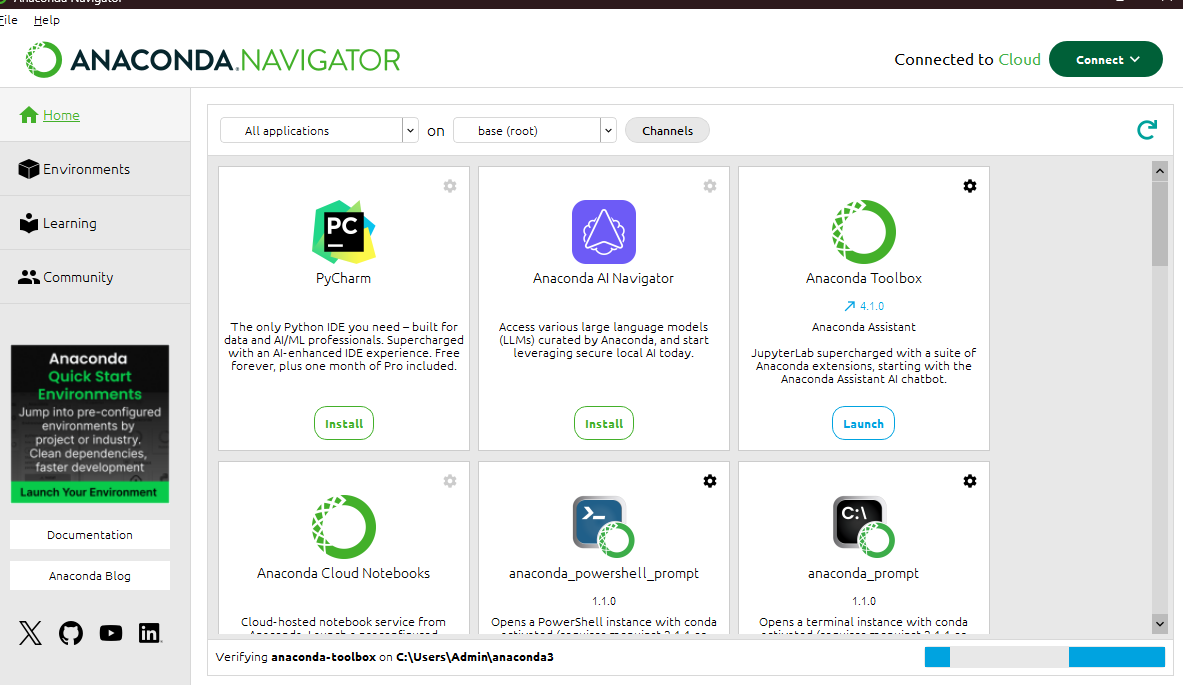

Bước 2.0.1 : 
Cài đặt môi trường ảo và thư viện trên anaconda 



# 0.2. Cài đặt vs code và jupyter 



 Bước 1.0.2: Cài đặt các extension trên vs code
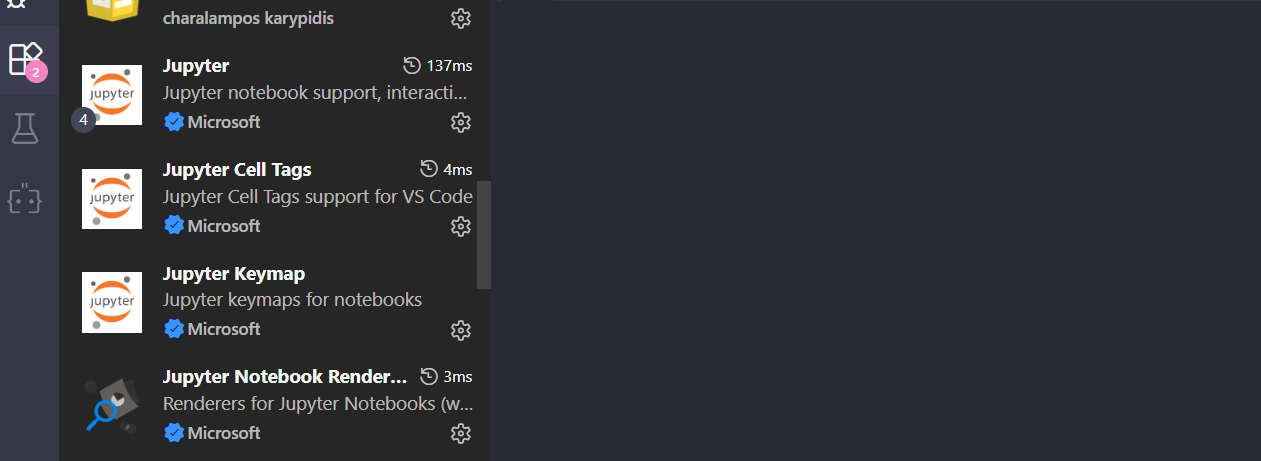

 Bước 2.0.2: Kết nối vs code với môi trường ảo 
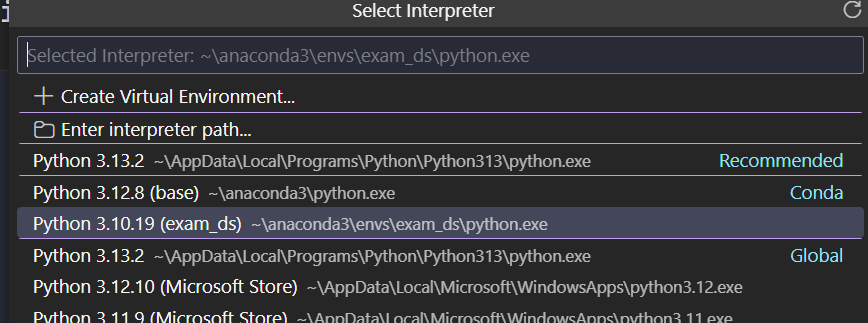

Bước 2.0.3 : Test môi trường ảo với việc import các thư viện vào notebook 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
try: 
    import sklearn 
    print("Cảnh báo sklearn bị cấm trong bài thi!") 
except ImportError:
    print("Môi trường ổn , sklearn không được cài đặt ")

Môi trường ổn , sklearn không được cài đặt 


# CÂU 1 : KHÁM PHÁ DỮ LIỆU VÀ TIỀN XỬ LÍ TỪ ĐẦU 

Câu 1.1.1 (1 điểm): Tổng quan về dữ liệu
Viết hàm dataset_overview(df) nhận vào một DataFrame và trả về các thông tin sau:
- Shape (kích thước): Số hàng và số cột của dữ liệu
- Dtypes (kiểu dữ liệu): Kiểu dữ liệu của từng cột (int, float, object...)
- Memory usage: Dung lượng bộ nhớ mà DataFrame đang chiếm
- Missing values: Đếm số lượng giá trị bị thiếu (NaN/null) trong mỗi cột
- Unique values: Đếm số lượng giá trị duy nhất (không trùng lặp) trong mỗi cột

In [ ]:
def dataset_overview(df): 
   shape = df.shape 
   Dtypes = df.dtypes 
   memory_usage = df.memory_usage(deep = True).sum()
   #deep = True để tính toán chính xác bộ nhớ cho các kiểu dữ liệu object 
   missing_value = df.isnull().sum()
   unique_values = df.nunique()
   results = {
      'Shape': shape,
      'Dtypes': Dtypes,
      'Memory usage': memory_usage,
      'Missing values': missing_value,
      'Unique values': unique_values
   }
   return results 

df_Employee_Attrition = pd.read_csv('Course Files/Employee_Attrition_Dataset.csv')
info = dataset_overview(df_Employee_Attrition)

print(f"Kích thước dataset {info['Shape']}")
print(f"Kiểu dữ liệu của dataset {info['Dtypes']}")
print(f"Tổng dung lượng bộ nhớ của dataset {info['Memory usage']}")
print(f"Tổng Missing values của dataset {info['Missing values']}")
print(f"Tổng unique values của dataset {info['Unique values']}")
print(df_Employee_Attrition.head(5))

Câu 1.1.2 (2 điểm): Phát hiện cột có phương sai bằng 0

In [3]:
def detect_zero_variance(df):
    cols_zero_variance = []
    for col_names in df.columns: 
        if df[col_names].nunique() == 1 :
            cols_zero_variance.append(col_names)
    return cols_zero_variance

zero_variance = detect_zero_variance(df_Employee_Attrition)
print(zero_variance)


['EmployeeCount', 'Over18', 'StandardHours']


Câu 1.1.3 (2 điểm): Phát hiện giá trị thiếu ẩn dưới dạng số 0

In [4]:
diabetes_df = pd.read_csv('Course Files/diabetes.csv')
info_diabetes_df = dataset_overview(diabetes_df)
print(info_diabetes_df)

#Sau khi kiểm tra info của dataset , nhận thấy ko có các giá trị missing values NaN => những giá trị missing values đã được ẩn về dạng 0 
#Kiểm tra các cột có giá trị 0 ko hợp tính logic như Glucose , BloodPressure , SkinThickness, Insulin , BMI

def detect_hidden_missing_value(df,cols):
    cols_with_zero = []
    for col in cols: 
      if(df[col] == 0).any(): #Kiểm tra bất kì giá trị .any() nào trong cột == 0
         cols_with_zero.append(col)
    return cols_with_zero

columns_with_zero = detect_hidden_missing_value(diabetes_df, ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', ])
print(columns_with_zero)      
    

{'Shape': (768, 9), 'Dtypes': Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object, 'Memory usage': np.int64(55424), 'Missing values': Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64, 'Unique values': Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                

Câu 1.1.4 (2 điểm): Phân tích tương quan

In [5]:
# print(df_Employee_Attrition.select_dtypes(include = ['number']).corr()['Attrition'].drop('Attrition'))
#Kiểm tra trước các hệ số tương quan trong mô hình xem có hệ số nào lớn hơn 0.5 để tránh bị array rỗng => lỗi
df_Employee_Attrition['Attrition'] = df_Employee_Attrition['Attrition'].map({
    'Yes': 1, 
    'No': 0
}) #Vì target feature có value chỉ là Yes và No , nên ko dùng làm correlation heatmap được vì vậy phải map sang 0 và 1 
def correlation_analysis(df , target_col , threshold = 0.5): 
    correlation_higher_threshold = []
    numeric_df = df.select_dtypes(include = ['number'])
    corr_series = numeric_df.corr()[target_col].drop(target_col) # tạo ra một series
    for cols_name , corr_values in corr_series.items():
        if abs(corr_values) > threshold: #Một hệ số tương quan gần -1 vẫn quan trọng 
            correlation_higher_threshold.append(cols_name)
    return correlation_higher_threshold

import seaborn as sns 
try : 
    columns_high_correlation = correlation_analysis(diabetes_df, 'Outcome')
    plt.figure(figsize = (12, 10))
    sns.heatmap(diabetes_df[columns_high_correlation].corr(), annot = True , cmap = 'coolwarm', fmt = ".2f")
    plt.title('Các feature với độ tương quan với feature mục tiêu lớn hơn threshold (0.5)')
    plt.show()
except ValueError as e: #Lỗi ValueError thường gặp
    print("Lỗi không thể vẽ heatmap , chi tiết lỗi có thể do feature nào đó không thỏa mãn điều kiện")
    print(f"Chi tiết lỗi:  {e}")
except Exception as e:
    print("Đã xảy ra lỗi không mong muốn khác ngoài ValueError")
    print(f"Chi tiết lỗi {e}")

#Error : Dù đã áp dụng ở hai dataset employee_attrition và diabetes nhưng ko có feature nào có mối tương quan lớn hơn threshold vì vậy gây ra lỗi 

Lỗi không thể vẽ heatmap , chi tiết lỗi có thể do feature nào đó không thỏa mãn điều kiện
Chi tiết lỗi:  zero-size array to reduction operation fmin which has no identity


<Figure size 1200x1000 with 0 Axes>

Câu 1.1.5 (1 điểm): Trực quan hóa phân phối dữ liệu

In [ ]:
def plot_distribution(df , cols): 
    for col in cols:
        if col not in df.columns:
            print(f"Cảnh báo cột {col} không tồn tại trong dataframe")
            continue 
        #Tạo một khung hình gồm 1 hàng 2 cột figsize (15,5)
        fig , axes = plt.subplots(1,2,figsize = (15,5)) 

        sns.histplot(df[col], kde = True , ax = axes[0] , color = 'skyblue')
        axes[0].set_title(f"Histogram of {col}")
        axes[0].set_ylabel("Frequency")
        axes[0].set_xlabel(col)

        sns.boxplot(x = df[col], ax = axes[1], color = 'salmon')
        axes[1].set_title(f"Boxplot of {col}")
        axes[1].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()

cols_plot = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
'BMI']    
plot_distribution(diabetes_df, cols_plot)

# Task 1.2: Làm Sạch Dữ Liệu từ Đầu (6 điểm)

Sử dụng file: Housing_prices_dataset.csv (dữ liệu về giá nhà)
Câu 1.2.1 (2 điểm): Chuẩn hóa dữ liệu phân loại

In [ ]:
def clean_categorical(df, cols ):
    
    for col in cols: 
        if col not in df.columns: 
            print(f"Columns không tồn tại trong dataframe")
            continue 
        df[col] == df[col].str.lower()

df_housing_price = pd.read_csv('Course Files/Housing_prices_dataset.csv')
print(df_housing_price.nunique())
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
clean_categorical(df_housing_price , categorical_cols)
print(df_housing_price.nunique())

Câu 1.2.2 (2 điểm): Phát hiện giá trị ngoại lai bằng phương pháp IQR

In [8]:
def detect_outliers_iqr(df , col): 
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df.loc[(df[col] < Q1 -1.5*IQR) | (df[col] > Q3 + 1.5 *IQR), col]
    #Vì khi thêm () sẽ tạo biểu thức boolean với toán thử or => nên kèm thêm df[] để lọc lại cái giá trị
    #df.loc(điều kiện lọc hàng , cột hay danh sách muốn hiển thị )
    return outliers
# print(df_housing_price)
detect_outliers_iqr(df_housing_price , 'price')


0     13300000
1     12250000
2     12250000
3     12215000
4     11410000
5     10850000
6     10150000
7     10150000
8      9870000
9      9800000
10     9800000
11     9681000
12     9310000
13     9240000
14     9240000
Name: price, dtype: int64

Câu 1.2.3 (2 điểm): Xử lý giá trị thiếu

In [ ]:

def handle_missing_value(df , stategy = 'median'):
    for col in df.columns:
       if df[col].dtypes in ['int64', 'float64']:
            if stategy == 'median': 
               fill_na = df[col].median()
            elif stategy == 'mean': 
                fill_na = df[col].mean()
            df[col] = df[col].fillna(fill_na)

handle_missing_value(df_housing_price)
print(df_housing_price.isnull().sum())

Task 1.3: Kỹ Thuật Tạo Đặc Trưng từ Đầu (6 điểm)
Câu 1.3.1 (2 điểm): Mã hóa One-Hot từ đầu

In [ ]:
def one_hot_scratch(df , cols , drop_first = True): 
    df_result = df.copy() #Tạo ra một copy của dataframe gốc để trả về giá trị 
    for col in cols: 
        if df_result[col].dtypes in ['object', 'category']: 
            unique_values = sorted(df[col].unique()) #Lặp qua từng columns , lấy giá trị unique đã sorted
            #Hàm nunique trả về 1 con số số lượng các giá trị duy nhất 
            #Hàm unique trả về 1 danh sách các giá trị duy nhất , có thể dùng sorted  
            if drop_first:  #Drop hàng đầu tiên trong danh sách của 1 column để tránh đa cộng tuyến 
                unique_values = unique_values[1:]
                #[1:] là bỏ phần tử đầu để lấy các phần tử còn lại
            for values in unique_values: #Lặp qua từng giá trị trong 1 column 
                new_col_names = f"{col}_{values}" #Tạo tên cho cột mới 
                df_result[new_col_names] = (df_result[col] == values).astype(int) #Cột mới = 1 nếu cột cũ bằng values và ngược lại 
            df_result = df_result.drop(col , axis = 1) #drop đi cột cũ trong dataframe 
            #Lỗi sai khi dùng df_result[col].drop() vì chỉ là một series đơn lẻ , nên sẽ ko còn gì để drop 
    return df_result

df_housing_price = one_hot_scratch(df_housing_price, df_housing_price.columns)
print(df_housing_price)

Câu 1.3.2 (2 điểm): Mã hóa Label từ đầu

In [ ]:
def label_encode_scratch(df , col):
    df_result = df.copy()

    unique_values = sorted(df[col].unique())
    i = 0
    for values in unique_values : 
        mapping_dict = {values: i}
        i+= 1
    df_result[col] = df_result[col].map(mapping_dict)
    return df_result, mapping_dict
#Nên dùng enumerate vì có tốc độ nhanh hơn for và ít bị lỗi đè index lên dictionary 


In [ ]:
def label_encode_scratch(df , col): 
    df_result = df.copy()
    unique_values = sorted(df_result[col].unique())
    mapping_dict = {label: i for i , label in enumerate(unique_values)}
    #enumerate() trả về danh sách gồm index:value 
    #gán index cho i , value cho label 
    #map thông thường {old_value : new_value}
    #map {label (tên hoa): i (index hoa)}
    df_result[col] = df_result[col].map(mapping_dict)
    return df_result , mapping_dict
df_iris = pd.read_csv('Course Files/iris.csv')
df_iris, df_iris_mapping_dict = label_encode_scratch(df_iris,'species')
print(df_iris)
print(df_iris_mapping_dict)

Câu 1.3.3 (2 điểm): Chuẩn hóa dữ liệu từ đầu

In [30]:
def train_test_split_scratch(X , y , test_size = 0.2 , random_state = 42): 
    if random_state: 
        np.random.seed(random_state)
    indicies = np.arange(len(X)) # tạo một mảng các chỉ số từ 0 đến len(x)
    np.random.shuffle(indicies) #xáo trộn cái mảng , trả về giá trị none nên ko gán cho variable khác
    test_size_len = int(len(X) * test_size) #lấy chiều dài của tập test 
    train_split = indicies[test_size_len:]
    test_split = indicies[:test_size_len]
    X_train , X_test = X.iloc[train_split], X.iloc[test_split] #đã có danh sách index thì train_split , test_split , dùng X để chia 
    y_train , y_test = y.iloc[train_split], y.iloc[test_split]
    return X_train , X_test , y_train , y_test 

X = df_housing_price.drop('price', axis = 1)
y = df_housing_price['price']
X_train , X_test , y_train , y_test = train_test_split_scratch(X, y)

def Z_score_normalization(X_train ,X_test ): 
    min = X_train.min()
    std = X_train.std()
    X_train_scaled = (X_train - min)/std 
    X_test_scaled = (X_test - min)/std
    min_std_mapping = { 
        'min': min, 
        'std': std
    }
    return X_train_scaled , X_test_scaled, min_std_mapping  


def min_max_normalization(X_train , X_test): 
    min = X_train.min()
    max = X_train.max()
    X_train_scaled = (X_train - min)/(max - min)
    X_test_scaled = (X_test - min)/ (max - min)
    max_min_mapping = { 
        'max': max , 
        'min': min
    }
    return X_train_scaled, X_test_scaled, max_min_mapping

X_train_scaled_Z_score, X_test_scaled_Z_score , min_sdt_mapping = Z_score_normalization(X_train , X_test)

X_train_scaled_min_max , X_test_scaled_min_max , max_min_mapping = min_max_normalization(X_train, X_test)
